# Using the number of occurrences as a feature in the matrix that i create, without limiting the number of occurrences
while also still removing adverbs that are part of an idiom

In [87]:
import grewpy
import yaml
import sys
import numpy as np

sys.path.insert(1, '/Users/madalina/Documents/M2TAL/stage/grex/grex2')
import pyximport
pyximport.install()
import grex.data
import grex.utils
import grex.features

In [88]:
path = "/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master"
grewpy.set_config('ud')
corpus = grewpy.Corpus(path)
draft = grewpy.CorpusDraft(corpus)

In [89]:
matches = corpus.search(grewpy.Request("X[upos=ADV]").without("X[InIdiom]").without("X[Idiom]"), clustering_parameter=['X.lemma'])

In [90]:
with open("patterns_adv_no_idioms.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

In [91]:
print(len(matches))

538


In [92]:
data = { k : list() for k in matches }
for adv, mts in matches.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)

In [93]:
unique_adv = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, matches in data.items() for m in matches for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_adv) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

In [57]:
print(unique_features)

['node:X:child:Definite=Def', 'node:X:child:Definite=Ind', 'node:X:child:Emph=No', 'node:X:child:Emph=Yes', 'node:X:child:ExtPos=ADP', 'node:X:child:ExtPos=ADV', 'node:X:child:ExtPos=CCONJ', 'node:X:child:ExtPos=NOUN', 'node:X:child:ExtPos=PRON', 'node:X:child:ExtPos=PROPN', 'node:X:child:ExtPos=SCONJ', 'node:X:child:Foreign=Yes', 'node:X:child:Gender=Fem', 'node:X:child:Gender=Masc', 'node:X:child:InTitle=Yes', 'node:X:child:Lang=en', 'node:X:child:Mood=Cnd', 'node:X:child:Mood=Ind', 'node:X:child:Mood=Sub', 'node:X:child:Number=Plur', 'node:X:child:Number=Sing', 'node:X:child:Number__psor=Sing', 'node:X:child:Person=1', 'node:X:child:Person=2', 'node:X:child:Person=3', 'node:X:child:Person__psor=3', 'node:X:child:Polarity=Neg', 'node:X:child:Poss=Yes', 'node:X:child:PronType=Art', 'node:X:child:PronType=Dem', 'node:X:child:PronType=Ind', 'node:X:child:PronType=Int', 'node:X:child:PronType=Prs', 'node:X:child:PronType=Rel', 'node:X:child:Reflex=Yes', 'node:X:child:Scrap=Yes', 'node:X:

In [94]:
# in the last column of the matrix have the number of samples for each adverb
X = np.zeros((len(data.keys()), len(unique_features)+1))
for adv, samples in data.items():
    n_samples = len(matches)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = X[adv2idx[adv]] / n_samples
    X[adv2idx[adv], -1] = len(samples)
print(f"{X.shape=}")

X.shape=(538, 188)


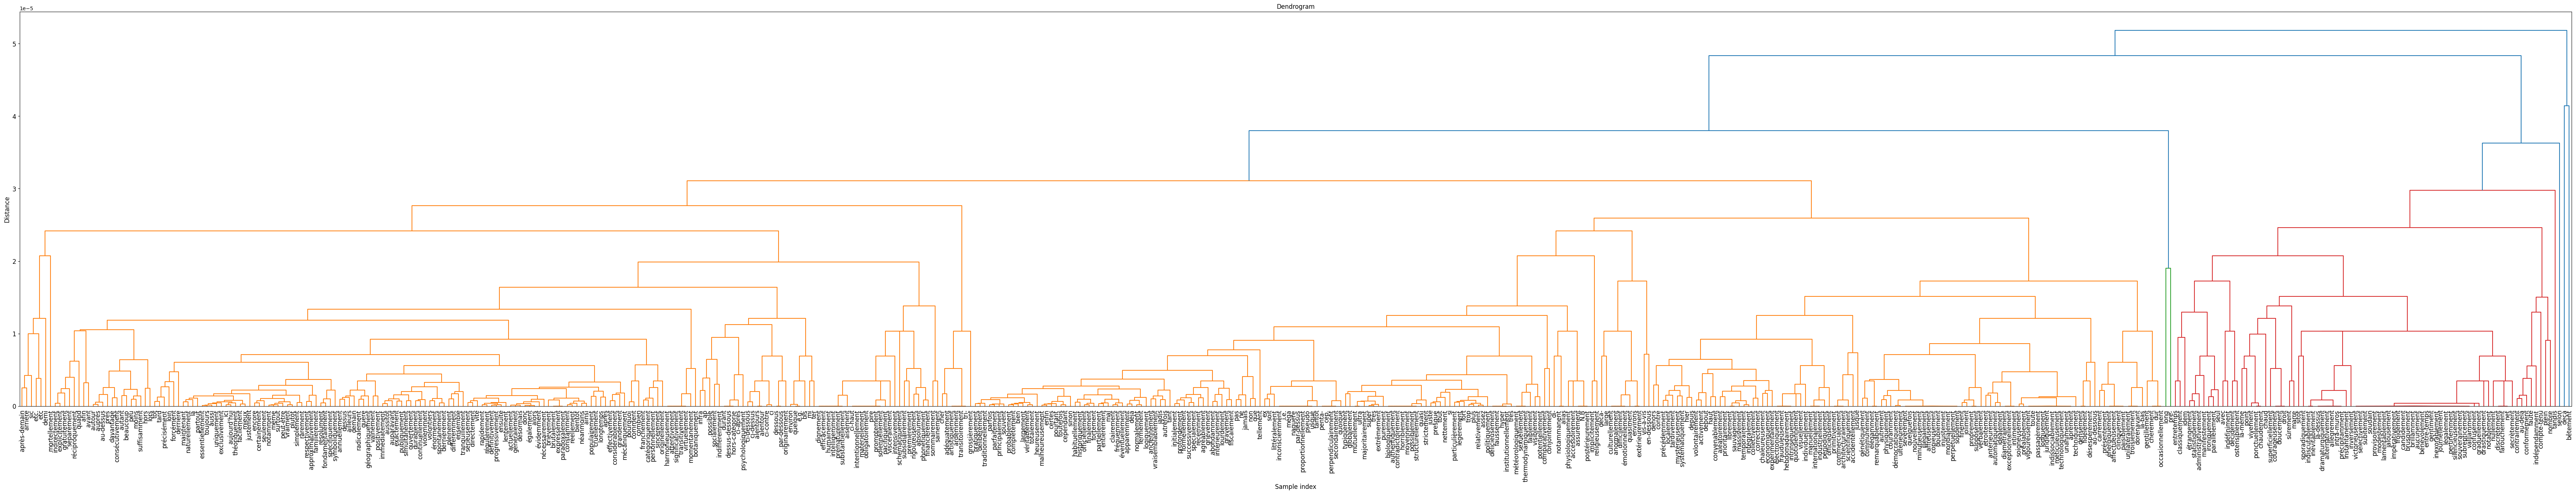

In [95]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
import matplotlib.pyplot as plt

# Hamming or jacard for categorical data, cosine for sparse matrices (normally used in NLP)
# I compute the distance for each pair of lines, each POS
distance_matrix = pdist(X, metric='cosine')
# Complete -> we cluster 
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)

plt.figure(figsize=(90, 14))

dn = dendrogram(linked,
                orientation='top',
                labels=[name for name in unique_adv],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

# Using the number of occurrences as a feature in the matrix that i create, also while limiting the number of occurrences
with eliminating adverbs in idioms
and changing instead of having the absolute number of occurrences of that lemma, instead having the percentage of that lemma out of all the adverbs (lemma count / total nb of adverbs)

In [75]:
all_matches = corpus.search(grewpy.Request("X[upos=ADV]").without("X[InIdiom]").without("X[Idiom]"), clustering_parameter=['X.lemma'])

In [96]:
import grewpy
from grewpy import Corpus, CorpusDraft, Request

req1 = Request("X[upos=ADV]").without("X[InIdiom]").without("X[Idiom]")
total_nb_adv_in_treebank = corpus.count(req1)

In [97]:
matches = {}
for key, value in all_matches.items():
    # remove those that have less than 10 occurrences
    if len(value) > 10:
        matches[key] = value

In [98]:
with open("patterns_adv_no_idioms.txt") as instream:
    config = yaml.load(instream, Loader=yaml.Loader)

templates = grex.utils.FeaturePredicate.from_config(config["templates"])
feature_predicate = grex.utils.FeaturePredicate.from_config(config["features"], templates=templates)

In [99]:
print(len(matches['ainsi']))

211


In [100]:
data = { k : list() for k in matches }
for adv, mts in matches.items():
    for match in mts:
        features = grex.data.extract_features(draft, match, feature_predicate)
        formatted_features = [
            f"{':'.join(k)}={v}" if not isinstance(v, set) else
            f"{':'.join(k)}={val}" for k, v in features.items() for val in (v if isinstance(v, set) else [v])
        ]
        data[adv].append(formatted_features)

In [101]:
unique_adv = sorted(set([k for k in data]))
unique_features = sorted(set([feat for _, matches in data.items() for m in matches for feat in m]))

idx2feature = {i : feat for i, feat in enumerate(unique_features) }
feature2idx = {feat : i for i, feat in idx2feature.items()}
idx2adv = {i : feat for i, feat in enumerate(unique_adv) }
adv2idx = {feat : i for i, feat in idx2adv.items()}

In [102]:
# in the last column of the matrix have the number of samples for each adverb
X = np.zeros((len(data.keys()), len(unique_features)+1))
for adv, samples in data.items():
    n_samples = len(matches)
    for m in samples:
        for feature in m:
            X[adv2idx[adv], feature2idx[feature]] += 1
    X[adv2idx[adv]] = X[adv2idx[adv]] / n_samples
    X[adv2idx[adv], -1] = len(samples) / total_nb_adv_in_treebank
print(f"{X.shape=}")

X.shape=(123, 186)


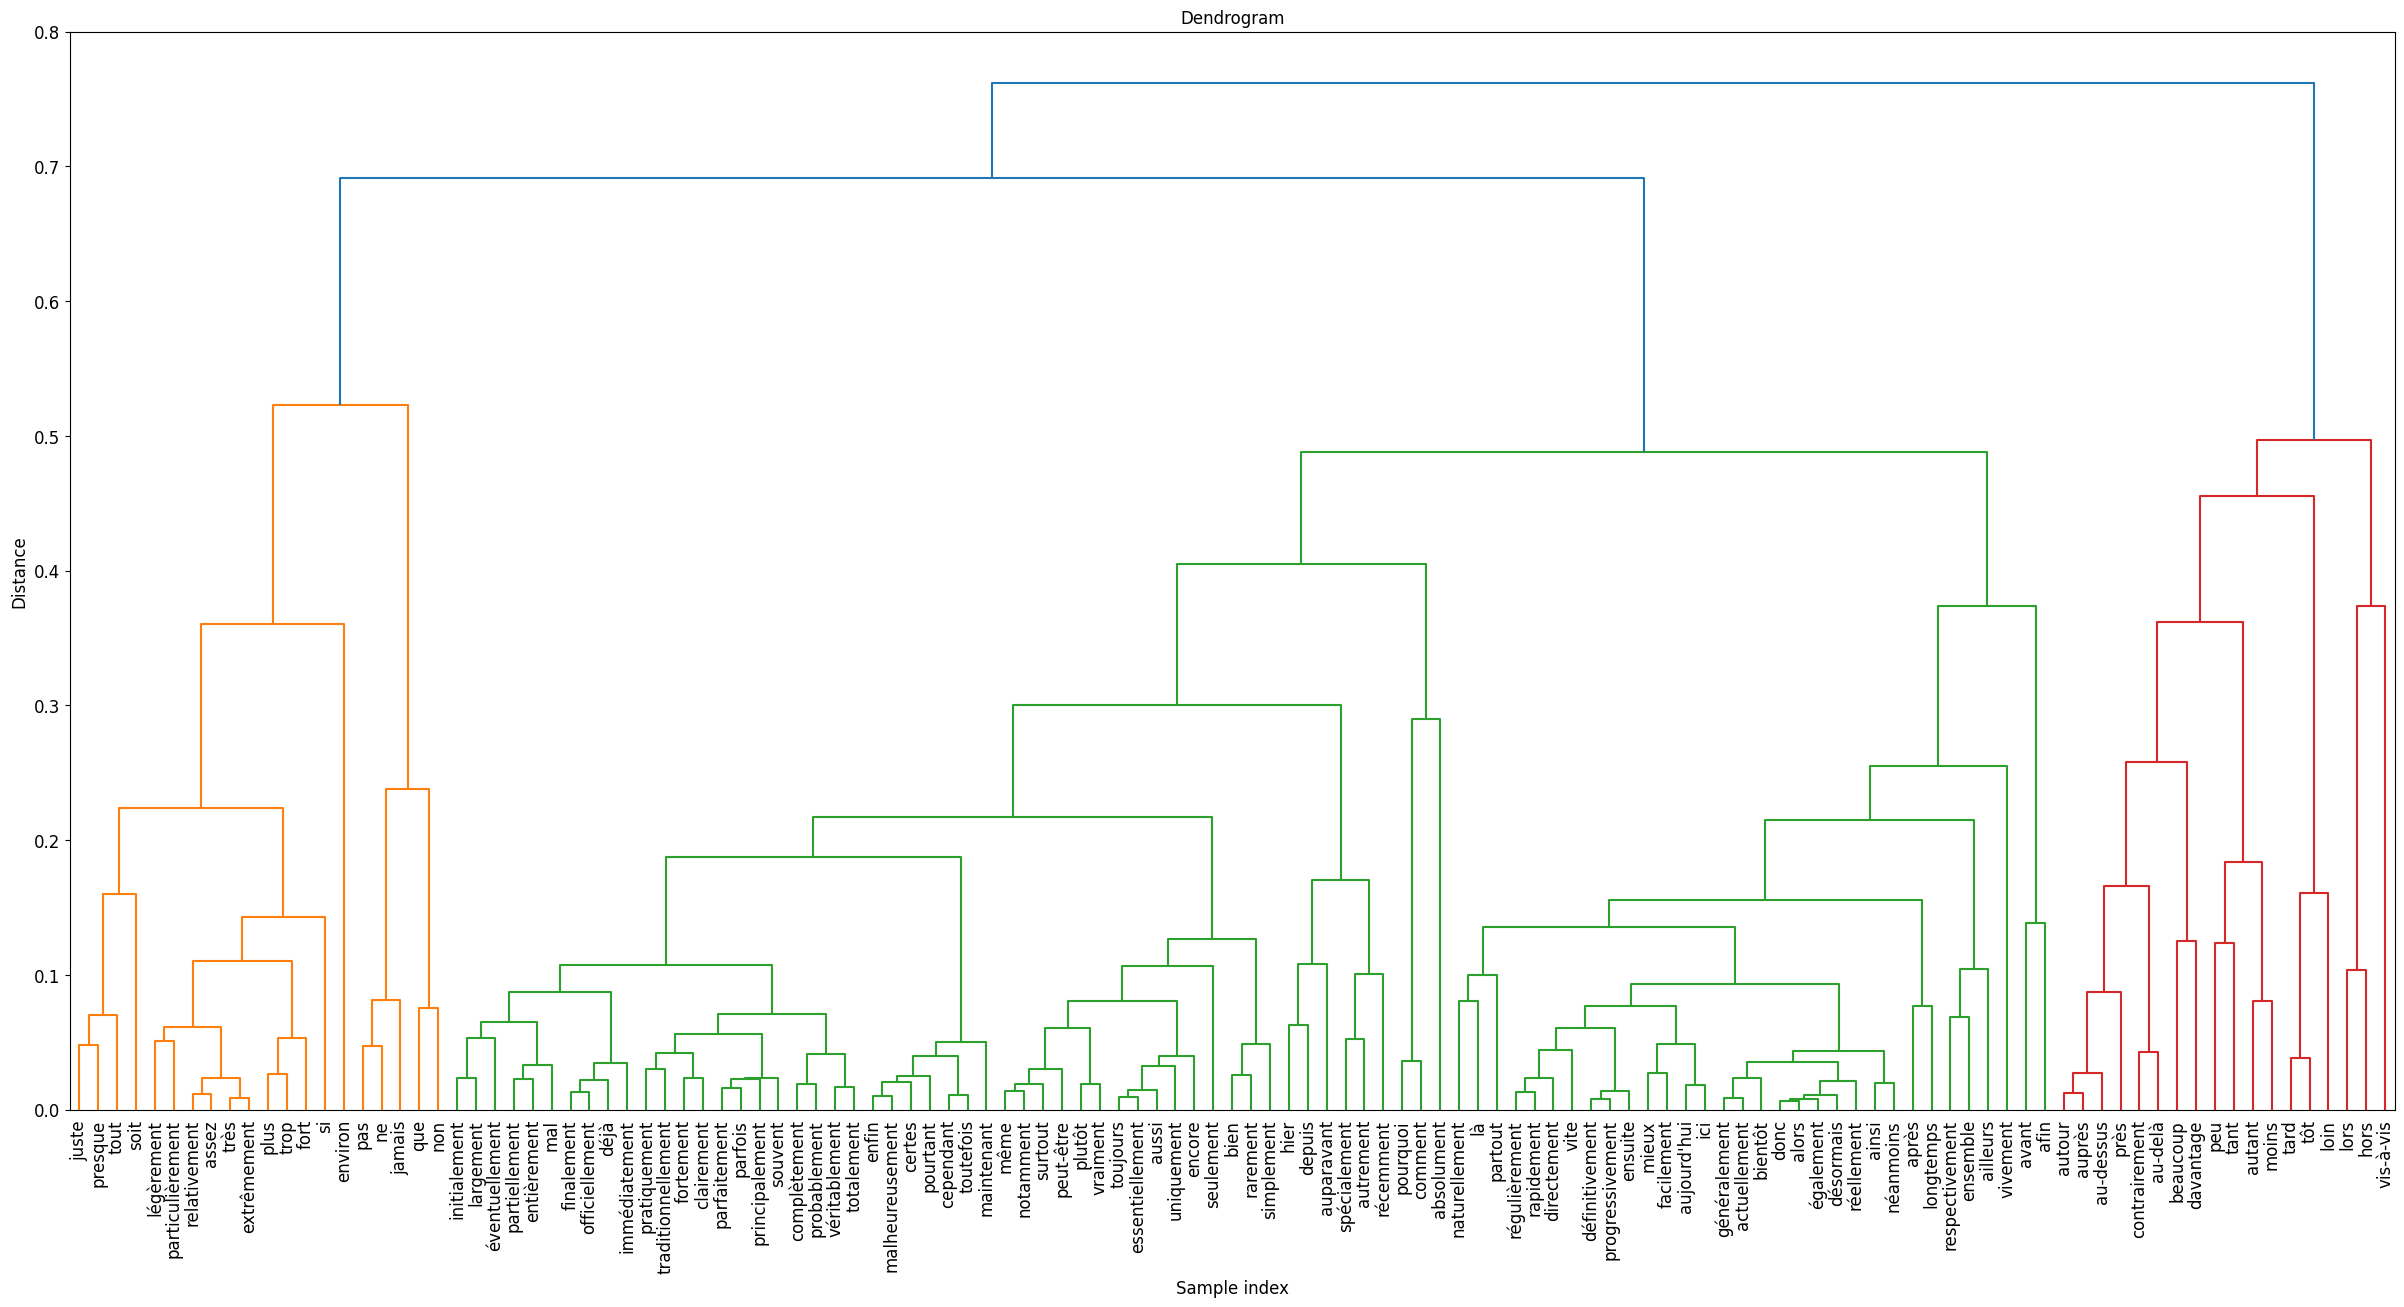

In [103]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
import matplotlib.pyplot as plt

# Hamming or jacard for categorical data, cosine for sparse matrices (normally used in NLP)
# I compute the distance for each pair of lines, each POS
distance_matrix = pdist(X, metric='cosine')
# Complete -> we cluster 
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)

plt.figure(figsize=(30, 14))

dn = dendrogram(linked,
                orientation='top',
                labels=[name for name in unique_adv],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

In [104]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

def find_optimal_clusters(X, max_clusters=20, metric='cosine', method='complete'):
    distance_matrix = pdist(X, metric=metric)
    linked = linkage(distance_matrix, method=method, optimal_ordering=True)
    
    silhouette_scores = []
    for num_clusters in range(2, max_clusters + 1):
        labels = fcluster(linked, num_clusters, criterion='maxclust')
        if len(np.unique(labels)) > 1:  # Ensure there is more than one cluster
            score = silhouette_score(X, labels, metric=metric)
            silhouette_scores.append(score)
            print(f'Number of clusters: {num_clusters}, Silhouette Score: {score}')
        else:
            silhouette_scores.append(-1)  # Append a low score if only one cluster
    
    optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2
    return optimal_clusters, silhouette_scores
optimal_clusters, silhouette_scores = find_optimal_clusters(X, max_clusters=50)
print(f'Optimal number of clusters: {optimal_clusters}')
print(X.shape)

Number of clusters: 2, Silhouette Score: 0.4686444203729069
Number of clusters: 3, Silhouette Score: 0.40896824151891337
Number of clusters: 4, Silhouette Score: 0.42172523071178253
Number of clusters: 5, Silhouette Score: 0.40000034558441994
Number of clusters: 6, Silhouette Score: 0.267953764629591
Number of clusters: 7, Silhouette Score: 0.28682008356248145
Number of clusters: 8, Silhouette Score: 0.2988756067202953
Number of clusters: 9, Silhouette Score: 0.30082876910948747
Number of clusters: 10, Silhouette Score: 0.2997642048077752
Number of clusters: 11, Silhouette Score: 0.3103080327568666
Number of clusters: 12, Silhouette Score: 0.3111923024353229
Number of clusters: 13, Silhouette Score: 0.29953601051972123
Number of clusters: 14, Silhouette Score: 0.3105007808885696
Number of clusters: 15, Silhouette Score: 0.3152656715021856
Number of clusters: 16, Silhouette Score: 0.30654117376801593
Number of clusters: 17, Silhouette Score: 0.3186537686376352
Number of clusters: 18, Si

In [105]:
# see what there is in each cluster
labels = fcluster(linked, optimal_clusters, criterion='maxclust')
clusters = {i: [] for i in range(1, optimal_clusters + 1)}
for i, label in enumerate(labels):
    clusters[label].append(i)

for cluster, members in clusters.items():
    print(f'Cluster {cluster}:')
    for member in members:
        print(f'  {unique_adv[member]}')

Cluster 1:
  au-delà
  au-dessus
  auprès
  autant
  autour
  beaucoup
  contrairement
  davantage
  hors
  loin
  lors
  moins
  peu
  près
  tant
  tard
  tôt
  vis-à-vis
Cluster 2:
  absolument
  actuellement
  afin
  ailleurs
  ainsi
  alors
  après
  assez
  aujourd'hui
  auparavant
  aussi
  autrement
  avant
  bien
  bientôt
  cependant
  certes
  clairement
  comment
  complètement
  depuis
  directement
  donc
  définitivement
  déjà
  désormais
  encore
  enfin
  ensemble
  ensuite
  entièrement
  environ
  essentiellement
  extrêmement
  facilement
  finalement
  fort
  fortement
  généralement
  hier
  ici
  immédiatement
  initialement
  jamais
  juste
  largement
  longtemps
  là
  légèrement
  maintenant
  mal
  malheureusement
  mieux
  même
  naturellement
  ne
  non
  notamment
  néanmoins
  officiellement
  parfaitement
  parfois
  particulièrement
  partiellement
  partout
  pas
  peut-être
  plus
  plutôt
  pourquoi
  pourtant
  pratiquement
  presque
  principalem

In [106]:
# seeing as the optimal clusters is 2, if we want to have more than that, 
# if we look at the dendrogram we sort of want to have 4 clusters
optimal_clusters = 4
labels = fcluster(linked, optimal_clusters, criterion='maxclust')
clusters = {i: [] for i in range(1, optimal_clusters + 1)}
for i, label in enumerate(labels):
    clusters[label].append(i)

for cluster, members in clusters.items():
    print(f'Cluster {cluster}:')
    for member in members:
        print(f'  {unique_adv[member]}')

Cluster 1:
  au-delà
  au-dessus
  auprès
  autant
  autour
  beaucoup
  contrairement
  davantage
  hors
  loin
  lors
  moins
  peu
  près
  tant
  tard
  tôt
  vis-à-vis
Cluster 2:
  absolument
  actuellement
  afin
  ailleurs
  ainsi
  alors
  après
  aujourd'hui
  auparavant
  aussi
  autrement
  avant
  bien
  bientôt
  cependant
  certes
  clairement
  comment
  complètement
  depuis
  directement
  donc
  définitivement
  déjà
  désormais
  encore
  enfin
  ensemble
  ensuite
  entièrement
  essentiellement
  facilement
  finalement
  fortement
  généralement
  hier
  ici
  immédiatement
  initialement
  largement
  longtemps
  là
  maintenant
  mal
  malheureusement
  mieux
  même
  naturellement
  notamment
  néanmoins
  officiellement
  parfaitement
  parfois
  partiellement
  partout
  peut-être
  plutôt
  pourquoi
  pourtant
  pratiquement
  principalement
  probablement
  progressivement
  rapidement
  rarement
  respectivement
  récemment
  réellement
  régulièrement
  s